In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from linearmodels.panel import PanelOLS, RandomEffects, PooledOLS
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Визуализация данных

In [2]:
banks = pd.read_excel("template_Profitability_static_v2.xlsx", sheet_name=None)

In [3]:
df = banks["total"]

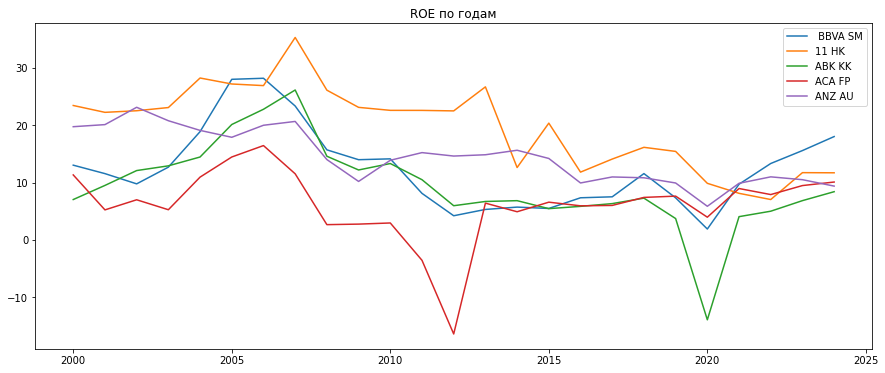

In [4]:
plt.figure(figsize=(15, 6))
i = 0
for bank_name, group in df.groupby("Ticker"):
    roe = np.array(group["Return on Common Equity"])
    if (roe == '—').sum() == 0:
        i += 1
        plt.plot(np.arange(2000, 2025), roe, label=bank_name)
    if i == 5:
        break
plt.legend()
plt.title("ROE по годам")
plt.show()

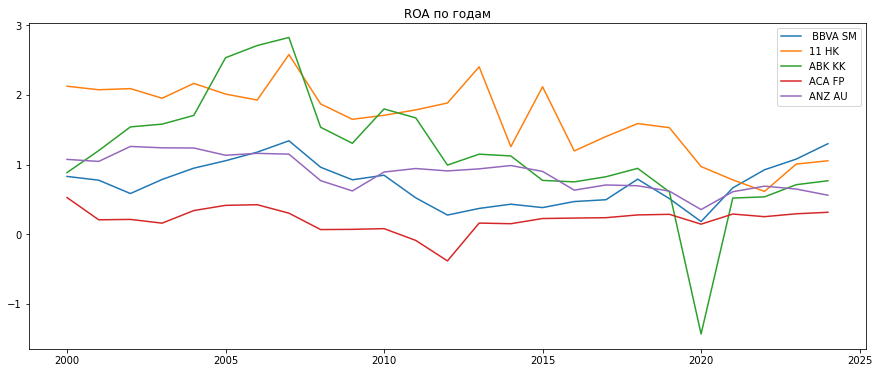

In [5]:
plt.figure(figsize=(15, 6))
i = 0
for bank_name, group in df.groupby("Ticker"):
    roa = np.array(group["Return on Assets"])
    if (roa == '—').sum() == 0:
        i += 1
        plt.plot(np.arange(2000, 2025), roa, label=bank_name)
    if i == 5:
        break
plt.title("ROA по годам")
plt.legend()
plt.show()

In [6]:
brent_oil = np.array([
    28.66, 24.46, 24.99, 28.85, 38.26, 54.57, 65.16, 72.44, 96.94, 61.74, 79.61,
    111.26, 111.63, 108.56, 98.97, 52.32, 43.64, 54.13, 71.34, 64.30, 41.96, 70.86, 100.93, 82.49, 80.52])

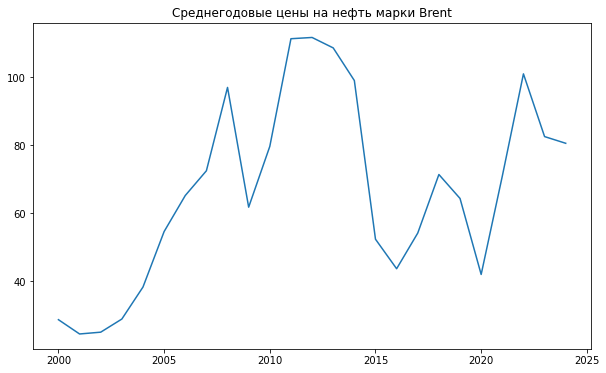

In [7]:
plt.figure(figsize=(10, 6))
plt.plot(np.arange(2000, 2025), np.array(brent_oil))
plt.title("Среднегодовые цены на нефть марки Brent")
plt.show()

# Матрица корреляции

In [8]:
banks_total = pd.read_excel("Banking_total.xlsx", sheet_name=None)
df = banks_total['TOTAL']
df_total = df[df["Year"] >  1999].copy()
df_total.loc[:, "Среднегодовая цена на нефть"] = np.tile(brent_oil, 70)

In [9]:
df_total["Среднегодовая цена на нефть за прошлый год"] = df_total.reset_index().groupby("Ticker")[ "Среднегодовая цена на нефть"].shift(1).values

In [10]:
df_total["Среднегодовая цена на нефть за позапрошлый год"] = df_total.reset_index().groupby("Ticker")["Среднегодовая цена на нефть"].shift(2).values

In [11]:
df_total["Среднегодовая цена на нефть (3 года назад)"] = df_total.reset_index().groupby("Ticker")["Среднегодовая цена на нефть"].shift(3).values

In [12]:
fed_data = pd.read_excel("FEDFUNDS.xlsx", sheet_name=None)
fed_data['Monthly']['YEAR'] = fed_data['Monthly']['observation_date'].dt.year
fed_data_year = (fed_data['Monthly'].groupby('YEAR')['FEDFUNDS'].mean())

df_total["Ставка ФРС"] = df_total['Year'].map(fed_data_year.to_dict())

In [13]:
shock_years = {
    1999: 0,
    2000: 0,
    2001: 0,
    2002: 0,
    2003: 0,
    2004: 0,
    2005: 0,
    2006: 0,
    2007: 0,
    2008: 1,
    2009: 0,
    2010: 0,
    2011: 0,
    2012: 0,
    2013: 0,
    2014: 1,
    2015: 0,
    2016: 0,
    2017: 0,
    2018: 0,
    2019: 0,
    2020: 1,
    2021: 0,
    2022: 0,
    2023: 0,
    2024: 0,
    2025: 0,
    2026: 0,
}

In [14]:
df_total["Шоковые года"] = df_total['Year'].map(shock_years)

In [15]:
bank_exporter = {
    '11 HK':     0,  # Гонконг
    '1288 HK':   0,  # Китай
    '601398 CH': 0,  # Китай
    '601939 CH': 0,  # Китай
    '601988 CH': 0,  # Китай
    'ABK KK':    1,  # Кувейт
    'ACA FP':    0,  # Франция
    'ANZ AU':    0,  # Австралия
    'BAC US':    1,  # США
    'BARC LN':   0,  # Великобритания
    'BBVA SM':   0,  # Испания
    'BMO CN':    1,  # Канада
    'BNP FP':    0,  # Франция
    'BNS CN':    1,  # Канада
    'C US':      1,  # США
    'CBK GY':    0,  # Германия
    'CSGN SW':   0,  # Швейцария
    'DBK GY':    0,  # Германия
    'DBS SP':    0,  # Сингапур
    'GLE FP':    0,  # Франция
    'GS US':     1,  # США
    'HSBA LN':   0,  # Великобритания
    'INGA NA':   0,  # Нидерланды
    'ISP IM':    0,  # Италия
    'JPM US':    1,  # США
    'LLOY LN':   0,  # Великобритания
    'MS US':     1,  # США
    'NBK KK':    1,  # Кувейт
    'NBOB OM':   1,  # Оман
    'NWG LN':    0,  # Великобритания
    'OCBC SP':   0,  # Сингапур
    'RBI AV':    0,  # Австрия
    'RJHI AB':   1,  # Саудовская Аравия
    'RY CN':     1,  # Канада
    'SAN SM':    0,  # Испания
    'SEBA SS':   0,  # Швеция
    'TD CN':     1,  # Канада
    'UBSG SW':   0,  # Швейцария
    'UCG IM':    0,  # Италия
    'UOB SP':    0,  # Сингапур
    'WFC US':    1,  # США
}

In [16]:
df_total["is_exporter"] = df_total['Ticker'].map(bank_exporter)
df_total["Цена на нефть * дамми-переменная экспортера"] = df_total["is_exporter"] * df_total["Среднегодовая цена на нефть"]

In [17]:
CONTROL_VARS =  ["Ставка ФРС", "Шоковые года", "Доля просроченных кредитов к общему объему кредитов",
    "Коэффициент покрытия ликвидности", "Логарифм капитала первого уровня банка",
    "Доля кредитов в совокупных активах", "Доля депозитов в общем объёме активов",
    "Коэффициент покрытия убытков по кредиту / 1000"]

DEPEND_VARS = ["Return on Common Equity", "Return on Assets"]

In [18]:
VARS = ["Среднегодовая цена на нефть"] + CONTROL_VARS + DEPEND_VARS

In [19]:
df_total.replace("", np.nan, inplace=True)
df_total.replace("—", np.nan, inplace=True)
df_clean = df_total.copy().dropna(subset=["Среднегодовая цена на нефть",  "Шоковые года",
    "Ставка ФРС", "Non-Perf Loans/Total Loans",
    "Total Loans/Total Assets", "Tier 1 Capital", "Loan Loss Coverage",
    "Total Assets", "Liquidity Coverage Ratio", "Deposits/Assets",
    "Return on Common Equity", "Return on Assets"])

<ipython-input-19-6dafe76b7910>:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_total.replace("—", np.nan, inplace=True)


In [20]:
df_clean["Логарифм капитала первого уровня банка"] = np.log(df_clean["Tier 1 Capital"])
df_clean["Доля просроченных кредитов к общему объему кредитов"] = df_clean["Non-Perf Loans/Total Loans"]
df_clean["Доля кредитов в совокупных активах"] = df_clean["Total Loans/Total Assets"]
df_clean["Коэффициент покрытия ликвидности"] = df_clean["Liquidity Coverage Ratio"]
df_clean["Доля депозитов в общем объёме активов"] = df_clean["Deposits/Assets"]
df_clean["Коэффициент покрытия убытков по кредиту / 1000"] = df_clean["Loan Loss Coverage"] / 1000
df_clean["Логарифм совокупных активов банка"] = np.log(df_clean["Total Assets"])

In [21]:
df_clean["Квадрат среднегодовой цены на нефть"] = df_clean["Среднегодовая цена на нефть"]**2

In [22]:
df_var = df_clean.reset_index()[VARS]

In [23]:
corr_matrix_pearson = df_var.corr(method='pearson').round(3)
corr_matrix_pearson

,Среднегодовая цена на нефть,Ставка ФРС,Шоковые года,Доля просроченных кредитов к общему объему кредитов,Коэффициент покрытия ликвидности,Логарифм капитала первого уровня банка,Доля кредитов в совокупных активах,Доля депозитов в общем объёме активов,Коэффициент покрытия убытков по кредиту / 1000,Return on Common Equity,Return on Assets
Среднегодовая цена на нефть,1.000,0.343,-0.249,-0.029,-0.143,0.105,-0.117,-0.138,0.019,0.117,0.033
Ставка ФРС,0.343,1.000,-0.310,-0.133,0.135,0.080,0.010,0.070,0.051,0.209,0.153
Шоковые года,-0.249,-0.310,1.000,0.090,-0.006,-0.011,-0.044,-0.072,-0.035,-0.203,-0.178
Доля просроченных кредитов к общему объему кредитов,-0.029,-0.133,0.090,1.000,-0.020,-0.090,0.025,-0.327,-0.057,-0.327,-0.319
Коэффициент покрытия ликвидности,-0.143,0.135,-0.006,-0.020,1.000,-0.508,0.210,0.131,-0.018,-0.038,0.059
Логарифм капитала первого уровня банка,0.105,0.080,-0.011,-0.090,-0.508,1.000,-0.332,0.052,-0.047,0.050,-0.034
Доля кредитов в совокупных активах,-0.117,0.010,-0.044,0.025,0.210,-0.332,1.000,0.693,-0.007,0.250,0.357
Доля депозитов в общем объёме активов,-0.138,0.070,-0.072,-0.327,0.131,0.052,0.693,1.000,0.011,0.433,0.537
Коэффициент покрытия убытков по кредиту / 1000,0.019,0.051,-0.035,-0.057,-0.018,-0.047,-0.007,0.011,1.000,0.106,0.094
Return on Common Equity,0.117,0.209,-0.203,-0.327,-0.038,0.050,0.250,0.433,0.106,1.000,0.868


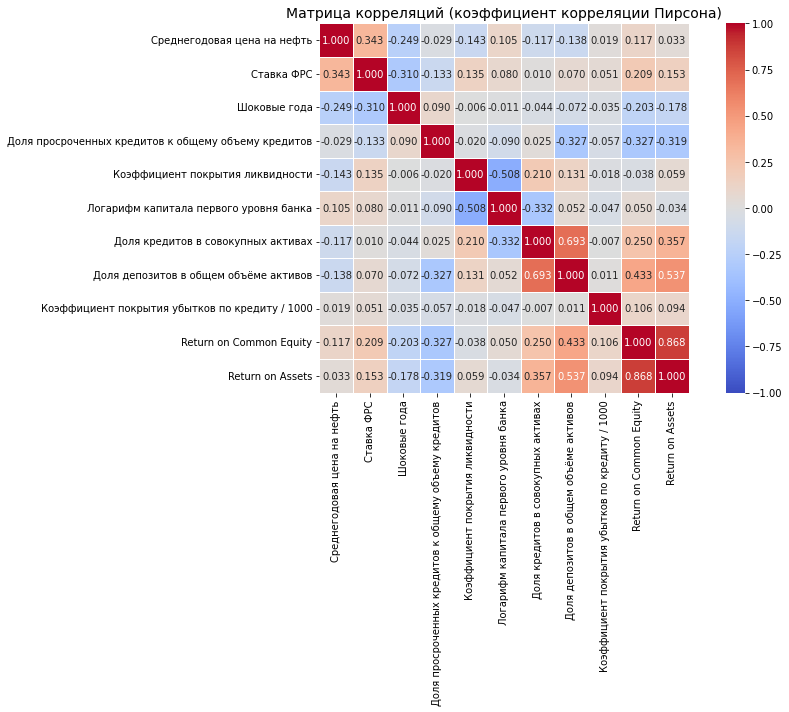

In [24]:
plt.figure(figsize=(14, 10))
sns.heatmap(
    corr_matrix_pearson,
    annot=True,      
    fmt='.3f',        
    cmap='coolwarm',
    vmin=-1, vmax=1,  
    square=True, 
    linewidths=0.5     
)
plt.title('Матрица корреляций (коэффициент корреляции Пирсона)', fontsize=14)
plt.tight_layout()
plt.savefig("pearson.png")
plt.show()

In [25]:
def calc_VIF(df_input, VARS):
    X = df_input[VARS].copy()
    
    X_norm = sm.add_constant(((X - X.mean()) / X.std()).values)
    X_norm = np.array(X_norm)

    for i in range(1, len(VARS) + 1):
        print(VARS[i - 1] + ": ", round(variance_inflation_factor(X_norm.astype(np.float64), i), 3))
calc_VIF(df_clean, ["Среднегодовая цена на нефть"] + CONTROL_VARS)

Среднегодовая цена на нефть:  1.247
Ставка ФРС:  1.312
Шоковые года:  1.147
Доля просроченных кредитов к общему объему кредитов:  1.354
Коэффициент покрытия ликвидности:  1.529
Логарифм капитала первого уровня банка:  1.956
Доля кредитов в совокупных активах:  3.152
Доля депозитов в общем объёме активов:  3.272
Коэффициент покрытия убытков по кредиту / 1000:  1.015


# Описательные статистики

In [26]:
rows = []
for var in VARS:
    if var != "Среднегодовая цена на нефть" and var != 'Шоковые года' and var != 'Ставка ФРС':
        values = df_clean[var]
        if var == "Return on Common Equity":
            var_name = "Рентабельность собственного капитала"
        elif var == "Return on Assets":
            var_name = "Рентабельность активов"
        else:
            var_name = var
        rows.append({
            'Переменная': var_name,
            'Количество': values.count(),
            'Среднее': round(values.mean(), 3),
            'Ст. отклонение': round(values.std(), 3),
            'Минимум': round(values.min(), 3),
            'Максимум': round(values.max(), 3)
        })
res = pd.DataFrame(rows)
print(res.to_string(index=False))

                                         Переменная  Количество  Среднее  Ст. отклонение  Минимум  Максимум
Доля просроченных кредитов к общему объему кредитов         378    2.093           2.313    0.147    17.748
                   Коэффициент покрытия ликвидности         378  141.081          32.073   60.980   315.000
             Логарифм капитала первого уровня банка         378   11.017           1.027    7.205    13.174
                 Доля кредитов в совокупных активах         378   46.790          13.798   10.614    83.789
              Доля депозитов в общем объёме активов         378   55.492          14.705   21.259    82.110
     Коэффициент покрытия убытков по кредиту / 1000         378    0.141           1.501  -13.594    16.741
               Рентабельность собственного капитала         378    9.223           6.503  -27.692    38.408
                             Рентабельность активов         378    0.683           0.529   -1.432     2.716


# Regression Models

In [27]:
VARS_MAIN = ["Среднегодовая цена на нефть"] + CONTROL_VARS

VARS_SQUARED = ["Среднегодовая цена на нефть", "Квадрат среднегодовой цены на нефть"] + CONTROL_VARS

VARS_LAG1 = ["Среднегодовая цена на нефть за прошлый год"] + CONTROL_VARS

VARS_LAG2 = ["Среднегодовая цена на нефть за позапрошлый год"] + CONTROL_VARS

VARS_LAG3 = ["Среднегодовая цена на нефть (3 года назад)"] + CONTROL_VARS

VARS_LAG0123 = ["Среднегодовая цена на нефть", "Среднегодовая цена на нефть за прошлый год",
                "Среднегодовая цена на нефть за позапрошлый год",
                "Среднегодовая цена на нефть (3 года назад)"] + CONTROL_VARS

VARS_EXPORTERS = ["Среднегодовая цена на нефть", "Квадрат среднегодовой цены на нефть", "Цена на нефть * дамми-переменная экспортера"] + CONTROL_VARS

VARS_TEST = ["Среднегодовая цена на нефть"] + CONTROL_VARS

In [28]:
df_clean = df_clean.set_index(['Ticker', 'Year'])

In [29]:
X = df_clean[VARS_MAIN]
X_c = sm.add_constant(X)

# Тест Хаусмана и Тест Бреуша-Пагана

In [30]:
def breusch_pagan_test(res_pooled_OLS, df):
    df_reset = df.reset_index()
    T       = df_reset['Year'].nunique()
    N       = df_reset['Ticker'].nunique()
    resids  = res_pooled_OLS.resids.values
    assert len(resids) == len(df_reset)

    df_with_resids = pd.DataFrame({
        'Ticker': df_reset['Ticker'].values,
        'Year':    df_reset['Year'].values,
        'resid':   resids
    })

    sum_2_sum_e = ((df_with_resids.groupby('Ticker')['resid'].sum()) ** 2).sum()
    sum_sum_e_2 = (df_with_resids['resid'] ** 2).sum()
    
    stat = N * T / (2 * (T - 1)) * (sum_2_sum_e / sum_sum_e_2 - 1) ** 2
    p_value = 1 - stats.chi2.cdf(stat, df=1)

    return p_value, N, T

def hausman_test(res_fe, res_re):
    vars_test = []
    for v in res_fe.params.index:
        vars_test.append(v)
    # print(vars_test)

    diff_beta = res_fe.params[vars_test].values - res_re.params[vars_test].values
    diff_cov = res_fe.cov.loc[vars_test, vars_test].values - res_re.cov.loc[vars_test, vars_test].values
    
    rang_cov = np.linalg.matrix_rank(diff_cov)

    print("ранг:", rang_cov)
    print("число переменных:", len(diff_cov))

    if rang_cov == len(vars_test):
        cov_inv = np.linalg.inv(diff_cov)
    else:
        cov_inv = np.linalg.pinv(diff_cov)
    p_value = 1 - stats.chi2.cdf(float(diff_beta @ cov_inv @ diff_beta), df=rang_cov)

    return p_value

In [31]:
# ROE

y = df_clean["Return on Common Equity"]

res_roe_pooled_OLS = PooledOLS(y, X).fit(cov_type='unadjusted')
res_roe_FE_test = PanelOLS(y, X, entity_effects=True, time_effects=False).fit(cov_type='unadjusted')
res_roe_RE_test = RandomEffects(y, X_c).fit(cov_type='unadjusted')

p_value, N, T = breusch_pagan_test(res_roe_pooled_OLS, df_clean)

print("Число банков:", N)
print("Число периодов:", T)
print("p-value:", round(p_value, 4))


if p_value < 0.05:
    print("Нужен тест Хаусмана")
else:
    print("Не отвергаем H0 (p > 0.05)")



p_value = hausman_test(res_roe_FE_test, res_roe_RE_test)
if p_value < 0.05:
    print(f"Отвергаем H0 (p < 0.05)")
    print("Выбор FE")
else:
    print("Выбор RE") 

Число банков: 41
Число периодов: 14
p-value: 0.0
Нужен тест Хаусмана
ранг: 9
число переменных: 9
Выбор RE


In [32]:
# ROA

y = df_clean["Return on Assets"]

res_roe_pooled_OLS = PooledOLS(y, X).fit(cov_type='unadjusted')
res_roe_FE_test = PanelOLS(y, X, entity_effects=True, time_effects=False).fit(cov_type='unadjusted')
res_roe_RE_test = RandomEffects(y, X_c).fit(cov_type='unadjusted')

p_value, N, T = breusch_pagan_test(res_roe_pooled_OLS, df_clean)

print("Число банков:", N)
print("Число периодов:", T)
print("p-value:", round(p_value, 4))


if p_value < 0.05:
    print("Нужен тест Хаусмана")
else:
    print("Не отвергаем H0 (p > 0.05)")



p_value = hausman_test(res_roe_FE_test, res_roe_RE_test)
if p_value < 0.05:
    print(f"Отвергаем H0 (p < 0.05)")
    print("Выбор FE")
else:
    print("Выбор RE") 

Число банков: 41
Число периодов: 14
p-value: 0.0
Нужен тест Хаусмана
ранг: 9
число переменных: 9
Выбор RE


# Гипотеза 1

In [33]:
y = df_clean["Return on Common Equity"]

res_roe_h1_RE = RandomEffects(y, X_c).fit(cov_type='clustered', cluster_entity=True)
res_roe_h1_RE

Dep. Variable:,Return on Common Equity,R-squared:,0.2281
Estimator:,RandomEffects,R-squared (Between):,0.2958
No. Observations:,378,R-squared (Within):,0.2147
Date:,"Wed, May 13 2026",R-squared (Overall):,0.2673
Time:,01:31:42,Log-likelihood,-1094.1
Cov. Estimator:,Clustered,,
,,F-statistic:,12.081
Entities:,41,P-value,0.0000
Avg Obs:,9.2195,Distribution:,"F(9,368)"
Min Obs:,1.0000,,
Max Obs:,14.000,F-statistic (robust):,7.1524


In [34]:
res_roe_h1_FE = PanelOLS(y, X, entity_effects=True, time_effects=False).fit(cov_type='clustered', cluster_entity=True)
res_roe_h1_FE

Dep. Variable:,Return on Common Equity,R-squared:,0.2281
Estimator:,PanelOLS,R-squared (Between):,0.4457
No. Observations:,378,R-squared (Within):,0.2281
Date:,"Wed, May 13 2026",R-squared (Overall):,0.3930
Time:,01:31:42,Log-likelihood,-1070.0
Cov. Estimator:,Clustered,,
,,F-statistic:,10.767
Entities:,41,P-value,0.0000
Avg Obs:,9.2195,Distribution:,"F(9,328)"
Min Obs:,1.0000,,
Max Obs:,14.000,F-statistic (robust):,7.1235


In [35]:
y = df_clean["Return on Assets"]

res_roa_h1_RE = RandomEffects(y, X_c).fit(cov_type='clustered', cluster_entity=True)
res_roa_h1_RE

Dep. Variable:,Return on Assets,R-squared:,0.2095
Estimator:,RandomEffects,R-squared (Between):,0.3753
No. Observations:,378,R-squared (Within):,0.1738
Date:,"Wed, May 13 2026",R-squared (Overall):,0.3465
Time:,01:31:42,Log-likelihood,-62.732
Cov. Estimator:,Clustered,,
,,F-statistic:,10.837
Entities:,41,P-value,0.0000
Avg Obs:,9.2195,Distribution:,"F(9,368)"
Min Obs:,1.0000,,
Max Obs:,14.000,F-statistic (robust):,10.638


In [36]:
res_roa_h1_FE = PanelOLS(y, X, entity_effects=True, time_effects=False).fit(cov_type='clustered', cluster_entity=True)
res_roa_h1_FE

Dep. Variable:,Return on Assets,R-squared:,0.1761
Estimator:,PanelOLS,R-squared (Between):,-0.8213
No. Observations:,378,R-squared (Within):,0.1761
Date:,"Wed, May 13 2026",R-squared (Overall):,-0.8022
Time:,01:31:43,Log-likelihood,-43.993
Cov. Estimator:,Clustered,,
,,F-statistic:,7.7902
Entities:,41,P-value,0.0000
Avg Obs:,9.2195,Distribution:,"F(9,328)"
Min Obs:,1.0000,,
Max Obs:,14.000,F-statistic (robust):,10.009


# Гипотеза 2 - Проверим лаг нефти

In [37]:
df1 = df_clean.dropna(subset = ["Среднегодовая цена на нефть за прошлый год"])
X1 = df1[VARS_LAG1]
X1_c = sm.add_constant(df1[VARS_LAG1])

In [38]:
df2 = df_clean.dropna(subset=["Среднегодовая цена на нефть за позапрошлый год"])
X2 = df2[VARS_LAG2]
X2_c = sm.add_constant(df2[VARS_LAG2])

In [39]:
df3 = df_clean.dropna(subset=["Среднегодовая цена на нефть (3 года назад)"])
X3 = df3[VARS_LAG3]
X3_c = sm.add_constant(df3[VARS_LAG3])

In [40]:
df0123 = df_clean.dropna(subset=[
    "Среднегодовая цена на нефть за прошлый год",
    "Среднегодовая цена на нефть за позапрошлый год",
    "Среднегодовая цена на нефть (3 года назад)"])
X0123 = df0123[VARS_LAG0123]
X0123_c = sm.add_constant(df0123[VARS_LAG0123])

### ROE

In [41]:
y1 = df1["Return on Common Equity"]

res_roe_h2_lag1_RE = RandomEffects(y1, X1_c).fit(cov_type='clustered', cluster_entity=True)
res_roe_h2_lag1_RE

Dep. Variable:,Return on Common Equity,R-squared:,0.2186
Estimator:,RandomEffects,R-squared (Between):,0.2958
No. Observations:,378,R-squared (Within):,0.2039
Date:,"Wed, May 13 2026",R-squared (Overall):,0.2585
Time:,01:31:46,Log-likelihood,-1096.8
Cov. Estimator:,Clustered,,
,,F-statistic:,11.438
Entities:,41,P-value,0.0000
Avg Obs:,9.2195,Distribution:,"F(9,368)"
Min Obs:,1.0000,,
Max Obs:,14.000,F-statistic (robust):,7.2130


In [42]:
res_roe_h2_lag1_FE = PanelOLS(y1, X1, entity_effects=True, time_effects=False).fit(cov_type='clustered', cluster_entity=True)
res_roe_h2_lag1_FE

Dep. Variable:,Return on Common Equity,R-squared:,0.2162
Estimator:,PanelOLS,R-squared (Between):,-0.3120
No. Observations:,378,R-squared (Within):,0.2162
Date:,"Wed, May 13 2026",R-squared (Overall):,-0.0754
Time:,01:31:47,Log-likelihood,-1072.8
Cov. Estimator:,Clustered,,
,,F-statistic:,10.052
Entities:,41,P-value,0.0000
Avg Obs:,9.2195,Distribution:,"F(9,328)"
Min Obs:,1.0000,,
Max Obs:,14.000,F-statistic (robust):,6.6929


In [43]:
y2 = df2["Return on Common Equity"]

res_roe_h2_lag2_RE = RandomEffects(y2, X2_c).fit(cov_type='clustered', cluster_entity=True)
res_roe_h2_lag2_RE

Dep. Variable:,Return on Common Equity,R-squared:,0.2166
Estimator:,RandomEffects,R-squared (Between):,0.3106
No. Observations:,378,R-squared (Within):,0.1992
Date:,"Wed, May 13 2026",R-squared (Overall):,0.2635
Time:,01:31:47,Log-likelihood,-1097.7
Cov. Estimator:,Clustered,,
,,F-statistic:,11.306
Entities:,41,P-value,0.0000
Avg Obs:,9.2195,Distribution:,"F(9,368)"
Min Obs:,1.0000,,
Max Obs:,14.000,F-statistic (robust):,8.3435


In [44]:
res_roe_h2_lag2_FE = PanelOLS(y2, X2, entity_effects=True, time_effects=False).fit(cov_type='clustered', cluster_entity=True)
res_roe_h2_lag2_FE

Dep. Variable:,Return on Common Equity,R-squared:,0.2084
Estimator:,PanelOLS,R-squared (Between):,0.7909
No. Observations:,378,R-squared (Within):,0.2084
Date:,"Wed, May 13 2026",R-squared (Overall):,0.7140
Time:,01:31:48,Log-likelihood,-1074.7
Cov. Estimator:,Clustered,,
,,F-statistic:,9.5951
Entities:,41,P-value,0.0000
Avg Obs:,9.2195,Distribution:,"F(9,328)"
Min Obs:,1.0000,,
Max Obs:,14.000,F-statistic (robust):,6.9788


In [45]:
y3 = df3["Return on Common Equity"]

res_roe_h2_lag3_RE = RandomEffects(y3, X3_c).fit(cov_type='clustered', cluster_entity=True)
res_roe_h2_lag3_RE

Dep. Variable:,Return on Common Equity,R-squared:,0.2161
Estimator:,RandomEffects,R-squared (Between):,0.3058
No. Observations:,378,R-squared (Within):,0.1996
Date:,"Wed, May 13 2026",R-squared (Overall):,0.2616
Time:,01:31:48,Log-likelihood,-1097.3
Cov. Estimator:,Clustered,,
,,F-statistic:,11.269
Entities:,41,P-value,0.0000
Avg Obs:,9.2195,Distribution:,"F(9,368)"
Min Obs:,1.0000,,
Max Obs:,14.000,F-statistic (robust):,7.0243


In [46]:
res_roe_h2_lag3_FE = PanelOLS(y3, X3, entity_effects=True, time_effects=False).fit(cov_type='clustered', cluster_entity=True)
res_roe_h2_lag3_FE

Dep. Variable:,Return on Common Equity,R-squared:,0.2085
Estimator:,PanelOLS,R-squared (Between):,0.7906
No. Observations:,378,R-squared (Within):,0.2085
Date:,"Wed, May 13 2026",R-squared (Overall):,0.7168
Time:,01:31:49,Log-likelihood,-1074.7
Cov. Estimator:,Clustered,,
,,F-statistic:,9.6002
Entities:,41,P-value,0.0000
Avg Obs:,9.2195,Distribution:,"F(9,328)"
Min Obs:,1.0000,,
Max Obs:,14.000,F-statistic (robust):,6.4022


In [47]:
y0123 = df0123["Return on Common Equity"]

res_roe_h2_lag0123_RE = RandomEffects(y0123, X0123_c).fit(cov_type='clustered', cluster_entity=True)
res_roe_h2_lag0123_RE

Dep. Variable:,Return on Common Equity,R-squared:,0.2300
Estimator:,RandomEffects,R-squared (Between):,0.2996
No. Observations:,378,R-squared (Within):,0.2155
Date:,"Wed, May 13 2026",R-squared (Overall):,0.2680
Time:,01:31:49,Log-likelihood,-1095.6
Cov. Estimator:,Clustered,,
,,F-statistic:,9.0866
Entities:,41,P-value,0.0000
Avg Obs:,9.2195,Distribution:,"F(12,365)"
Min Obs:,1.0000,,
Max Obs:,14.000,F-statistic (robust):,8.7016


In [48]:
res_roe_h2_lag0123_FE = PanelOLS(y0123, X0123, entity_effects=True, time_effects=False).fit(cov_type='clustered', cluster_entity=True)
res_roe_h2_lag0123_FE

Dep. Variable:,Return on Common Equity,R-squared:,0.2306
Estimator:,PanelOLS,R-squared (Between):,0.6133
No. Observations:,378,R-squared (Within):,0.2306
Date:,"Wed, May 13 2026",R-squared (Overall):,0.6339
Time:,01:31:50,Log-likelihood,-1069.3
Cov. Estimator:,Clustered,,
,,F-statistic:,8.1178
Entities:,41,P-value,0.0000
Avg Obs:,9.2195,Distribution:,"F(12,325)"
Min Obs:,1.0000,,
Max Obs:,14.000,F-statistic (robust):,9.1007


### ROA

In [49]:
y1 = df1["Return on Assets"]

res_roa_h2_lag1_RE = RandomEffects(y1, X1_c).fit(cov_type='clustered', cluster_entity=True)
res_roa_h2_lag1_RE

Dep. Variable:,Return on Assets,R-squared:,0.2093
Estimator:,RandomEffects,R-squared (Between):,0.3728
No. Observations:,378,R-squared (Within):,0.1743
Date:,"Wed, May 13 2026",R-squared (Overall):,0.3436
Time:,01:31:51,Log-likelihood,-62.549
Cov. Estimator:,Clustered,,
,,F-statistic:,10.823
Entities:,41,P-value,0.0000
Avg Obs:,9.2195,Distribution:,"F(9,368)"
Min Obs:,1.0000,,
Max Obs:,14.000,F-statistic (robust):,10.711


In [50]:
res_roa_h2_lag1_FE = PanelOLS(y1, X1, entity_effects=True, time_effects=False).fit(cov_type='clustered', cluster_entity=True)
res_roa_h2_lag1_FE

Dep. Variable:,Return on Assets,R-squared:,0.1754
Estimator:,PanelOLS,R-squared (Between):,0.5936
No. Observations:,378,R-squared (Within):,0.1754
Date:,"Wed, May 13 2026",R-squared (Overall):,0.5257
Time:,01:31:52,Log-likelihood,-44.156
Cov. Estimator:,Clustered,,
,,F-statistic:,7.7523
Entities:,41,P-value,0.0000
Avg Obs:,9.2195,Distribution:,"F(9,328)"
Min Obs:,1.0000,,
Max Obs:,14.000,F-statistic (robust):,9.2072


In [51]:
y2 = df2["Return on Assets"]

res_roa_h2_lag2_RE = RandomEffects(y2, X2_c).fit(cov_type='clustered', cluster_entity=True)
res_roa_h2_lag2_RE

Dep. Variable:,Return on Assets,R-squared:,0.2074
Estimator:,RandomEffects,R-squared (Between):,0.3744
No. Observations:,378,R-squared (Within):,0.1707
Date:,"Wed, May 13 2026",R-squared (Overall):,0.3431
Time:,01:31:53,Log-likelihood,-63.840
Cov. Estimator:,Clustered,,
,,F-statistic:,10.697
Entities:,41,P-value,0.0000
Avg Obs:,9.2195,Distribution:,"F(9,368)"
Min Obs:,1.0000,,
Max Obs:,14.000,F-statistic (robust):,10.375


In [52]:
res_roa_h2_lag2_FE = PanelOLS(y2, X2, entity_effects=True, time_effects=False).fit(cov_type='clustered', cluster_entity=True)
res_roa_h2_lag2_FE

Dep. Variable:,Return on Assets,R-squared:,0.1719
Estimator:,PanelOLS,R-squared (Between):,-0.0760
No. Observations:,378,R-squared (Within):,0.1719
Date:,"Wed, May 13 2026",R-squared (Overall):,-0.1038
Time:,01:31:53,Log-likelihood,-44.968
Cov. Estimator:,Clustered,,
,,F-statistic:,7.5627
Entities:,41,P-value,0.0000
Avg Obs:,9.2195,Distribution:,"F(9,328)"
Min Obs:,1.0000,,
Max Obs:,14.000,F-statistic (robust):,9.6514


In [53]:
y3 = df3["Return on Assets"]

res_roa_h2_lag3_RE = RandomEffects(y3, X3_c).fit(cov_type='clustered', cluster_entity=True)
res_roa_h2_lag3_RE

Dep. Variable:,Return on Assets,R-squared:,0.2073
Estimator:,RandomEffects,R-squared (Between):,0.3744
No. Observations:,378,R-squared (Within):,0.1710
Date:,"Wed, May 13 2026",R-squared (Overall):,0.3429
Time:,01:31:54,Log-likelihood,-63.550
Cov. Estimator:,Clustered,,
,,F-statistic:,10.691
Entities:,41,P-value,0.0000
Avg Obs:,9.2195,Distribution:,"F(9,368)"
Min Obs:,1.0000,,
Max Obs:,14.000,F-statistic (robust):,10.271


In [54]:
res_roa_h2_lag3_FE = PanelOLS(y3, X3, entity_effects=True, time_effects=False).fit(cov_type='clustered', cluster_entity=True)
res_roa_h2_lag3_FE

Dep. Variable:,Return on Assets,R-squared:,0.1720
Estimator:,PanelOLS,R-squared (Between):,-0.0037
No. Observations:,378,R-squared (Within):,0.1720
Date:,"Wed, May 13 2026",R-squared (Overall):,-0.0356
Time:,01:31:55,Log-likelihood,-44.930
Cov. Estimator:,Clustered,,
,,F-statistic:,7.5716
Entities:,41,P-value,0.0000
Avg Obs:,9.2195,Distribution:,"F(9,328)"
Min Obs:,1.0000,,
Max Obs:,14.000,F-statistic (robust):,9.3212


In [55]:
y0123 = df0123["Return on Assets"]

res_roa_h2_lag0123_RE = RandomEffects(y0123, X0123_c).fit(cov_type='clustered', cluster_entity=True)
res_roa_h2_lag0123_RE

Dep. Variable:,Return on Assets,R-squared:,0.2115
Estimator:,RandomEffects,R-squared (Between):,0.3732
No. Observations:,378,R-squared (Within):,0.1771
Date:,"Wed, May 13 2026",R-squared (Overall):,0.3452
Time:,01:31:56,Log-likelihood,-61.783
Cov. Estimator:,Clustered,,
,,F-statistic:,8.1569
Entities:,41,P-value,0.0000
Avg Obs:,9.2195,Distribution:,"F(12,365)"
Min Obs:,1.0000,,
Max Obs:,14.000,F-statistic (robust):,8.9664


In [56]:
res_roa_h2_lag0123_FE = PanelOLS(y0123, X0123, entity_effects=True, time_effects=False).fit(cov_type='clustered', cluster_entity=True)
res_roa_h2_lag0123_FE

Dep. Variable:,Return on Assets,R-squared:,0.1787
Estimator:,PanelOLS,R-squared (Between):,0.4951
No. Observations:,378,R-squared (Within):,0.1787
Date:,"Wed, May 13 2026",R-squared (Overall):,0.4330
Time:,01:31:57,Log-likelihood,-43.408
Cov. Estimator:,Clustered,,
,,F-statistic:,5.8911
Entities:,41,P-value,0.0000
Avg Obs:,9.2195,Distribution:,"F(12,325)"
Min Obs:,1.0000,,
Max Obs:,14.000,F-statistic (robust):,8.0434


# Гипотеза 3 - нелинейность, добавим квадрат цен на нефть

In [57]:
X = df_clean[VARS_SQUARED]
X_c = sm.add_constant(df_clean[VARS_SQUARED])

In [58]:
y = df_clean["Return on Common Equity"]

res_roe_h3_RE = RandomEffects(y, X_c).fit(cov_type='clustered', cluster_entity=True)
res_roe_h3_RE

Dep. Variable:,Return on Common Equity,R-squared:,0.2482
Estimator:,RandomEffects,R-squared (Between):,0.3019
No. Observations:,378,R-squared (Within):,0.2372
Date:,"Wed, May 13 2026",R-squared (Overall):,0.2827
Time:,01:31:58,Log-likelihood,-1087.9
Cov. Estimator:,Clustered,,
,,F-statistic:,12.116
Entities:,41,P-value,0.0000
Avg Obs:,9.2195,Distribution:,"F(10,367)"
Min Obs:,1.0000,,
Max Obs:,14.000,F-statistic (robust):,6.9968


In [59]:
res_roe_h3_FE = PanelOLS(y, X, entity_effects=True, time_effects=False).fit(cov_type='clustered', cluster_entity=True)
res_roe_h3_FE

Dep. Variable:,Return on Common Equity,R-squared:,0.2489
Estimator:,PanelOLS,R-squared (Between):,0.6629
No. Observations:,378,R-squared (Within):,0.2489
Date:,"Wed, May 13 2026",R-squared (Overall):,0.6222
Time:,01:31:59,Log-likelihood,-1064.8
Cov. Estimator:,Clustered,,
,,F-statistic:,10.837
Entities:,41,P-value,0.0000
Avg Obs:,9.2195,Distribution:,"F(10,327)"
Min Obs:,1.0000,,
Max Obs:,14.000,F-statistic (robust):,6.7753


In [60]:
y = df_clean["Return on Assets"]

res_roa_h3_RE = RandomEffects(y, X_c).fit(cov_type='clustered', cluster_entity=True)
res_roa_h3_RE

Dep. Variable:,Return on Assets,R-squared:,0.2304
Estimator:,RandomEffects,R-squared (Between):,0.3745
No. Observations:,378,R-squared (Within):,0.1994
Date:,"Wed, May 13 2026",R-squared (Overall):,0.3551
Time:,01:32:00,Log-likelihood,-56.510
Cov. Estimator:,Clustered,,
,,F-statistic:,10.988
Entities:,41,P-value,0.0000
Avg Obs:,9.2195,Distribution:,"F(10,367)"
Min Obs:,1.0000,,
Max Obs:,14.000,F-statistic (robust):,12.873


In [61]:
res_roa_h3_FE = PanelOLS(y, X, entity_effects=True, time_effects=False).fit(cov_type='clustered', cluster_entity=True)
res_roa_h3_FE

Dep. Variable:,Return on Assets,R-squared:,0.2027
Estimator:,PanelOLS,R-squared (Between):,-0.2132
No. Observations:,378,R-squared (Within):,0.2027
Date:,"Wed, May 13 2026",R-squared (Overall):,-0.2331
Time:,01:32:00,Log-likelihood,-37.805
Cov. Estimator:,Clustered,,
,,F-statistic:,8.3109
Entities:,41,P-value,0.0000
Avg Obs:,9.2195,Distribution:,"F(10,327)"
Min Obs:,1.0000,,
Max Obs:,14.000,F-statistic (robust):,9.0532


# Гипотеза 4 - экспортеры и импортеры, добавим переменную brent * is_exporter

In [62]:
X = df_clean[VARS_EXPORTERS]
X_c = sm.add_constant(df_clean[VARS_EXPORTERS])

In [63]:
y = df_clean["Return on Common Equity"]

res_roe_h4_RE = RandomEffects(y, X_c).fit(cov_type='clustered', cluster_entity=True)
res_roe_h4_RE

Dep. Variable:,Return on Common Equity,R-squared:,0.2485
Estimator:,RandomEffects,R-squared (Between):,0.3066
No. Observations:,378,R-squared (Within):,0.2367
Date:,"Wed, May 13 2026",R-squared (Overall):,0.2842
Time:,01:32:02,Log-likelihood,-1088.3
Cov. Estimator:,Clustered,,
,,F-statistic:,11.002
Entities:,41,P-value,0.0000
Avg Obs:,9.2195,Distribution:,"F(11,366)"
Min Obs:,1.0000,,
Max Obs:,14.000,F-statistic (robust):,10.919


In [64]:
res_roe_h4_FE = PanelOLS(y, X, entity_effects=True, time_effects=False).fit(cov_type='clustered', cluster_entity=True)
res_roe_h4_FE

Dep. Variable:,Return on Common Equity,R-squared:,0.2489
Estimator:,PanelOLS,R-squared (Between):,0.6634
No. Observations:,378,R-squared (Within):,0.2489
Date:,"Wed, May 13 2026",R-squared (Overall):,0.6228
Time:,01:32:02,Log-likelihood,-1064.8
Cov. Estimator:,Clustered,,
,,F-statistic:,9.8220
Entities:,41,P-value,0.0000
Avg Obs:,9.2195,Distribution:,"F(11,326)"
Min Obs:,1.0000,,
Max Obs:,14.000,F-statistic (robust):,7.1439


In [65]:
y = df_clean["Return on Assets"]

res_roa_h4_RE = RandomEffects(y, X_c).fit(cov_type='clustered', cluster_entity=True)
res_roa_h4_RE

Dep. Variable:,Return on Assets,R-squared:,0.2367
Estimator:,RandomEffects,R-squared (Between):,0.4181
No. Observations:,378,R-squared (Within):,0.1962
Date:,"Wed, May 13 2026",R-squared (Overall):,0.3800
Time:,01:32:03,Log-likelihood,-58.279
Cov. Estimator:,Clustered,,
,,F-statistic:,10.320
Entities:,41,P-value,0.0000
Avg Obs:,9.2195,Distribution:,"F(11,366)"
Min Obs:,1.0000,,
Max Obs:,14.000,F-statistic (robust):,15.879


In [66]:
res_roa_h4_FE = PanelOLS(y, X, entity_effects=True, time_effects=False).fit(cov_type='clustered', cluster_entity=True)
res_roa_h4_FE

Dep. Variable:,Return on Assets,R-squared:,0.2028
Estimator:,PanelOLS,R-squared (Between):,-0.1499
No. Observations:,378,R-squared (Within):,0.2028
Date:,"Wed, May 13 2026",R-squared (Overall):,-0.1716
Time:,01:32:03,Log-likelihood,-37.768
Cov. Estimator:,Clustered,,
,,F-statistic:,7.5396
Entities:,41,P-value,0.0000
Avg Obs:,9.2195,Distribution:,"F(11,326)"
Min Obs:,1.0000,,
Max Obs:,14.000,F-statistic (robust):,8.5121
